In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
df = pd.read_excel("Cleaned_ABS_Tech_Case_2026_Data.xlsx")

## Self-reported reasons for voluntary termination

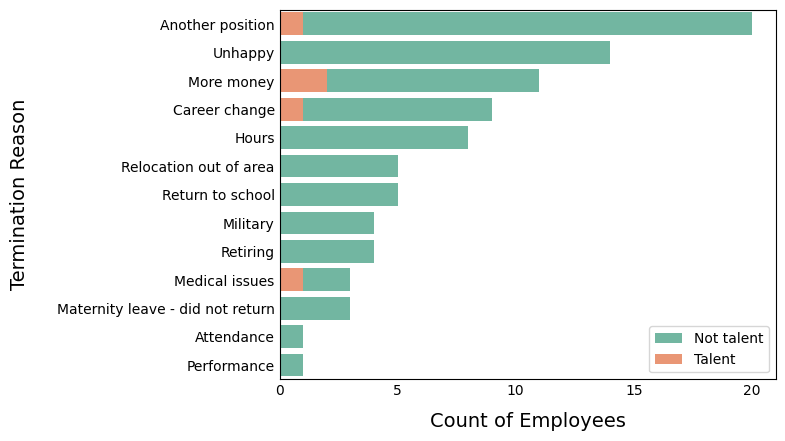

In [38]:
df["TermReason"] = df["TermReason"].astype(str).str.capitalize()

term = df[df["Termd"] == 1]
ct = pd.crosstab(term["TermReason"], [term["EmploymentStatus"], term["is_talent"]])

vol_counts = ct["Voluntarily Terminated"].fillna(0)
vol_counts["Total"] = vol_counts[0] + vol_counts[1]
vol_counts = vol_counts[vol_counts["Total"] > 0].sort_values("Total", ascending=False)

palette = sns.color_palette("Set2", n_colors=2)

sns.barplot(x=vol_counts["Total"], y=vol_counts.index, color=palette[0], label="Not talent")
sns.barplot(x=vol_counts[1], y=vol_counts.index, color=palette[1], label="Talent")

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

ax.grid(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.xlabel("Count of Employees", fontsize=14, labelpad=10)
plt.ylabel("Termination Reason", fontsize=14, labelpad=20)

plt.legend()
plt.show()

## Stat. significant variables

## Random forest for coefficient importance

## Talent VS Non-talent